In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split, Subset

In [2]:
EUROSAT_PATH = "../dataset/EuroSAT"

dataset = ImageFolder(EUROSAT_PATH)

print("Total Images :", len(dataset))
print("Classes :", len(dataset.classes))
print(dataset.classes)

Total Images : 27000
Classes : 10
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [3]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

random_train, random_val = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Random Train :", len(random_train))
print("Random Validation :", len(random_val))

Random Train : 21600
Random Validation : 5400


In [4]:
indices = list(range(len(dataset)))

block_size = 500

blocks = [
    indices[i:i + block_size]
    for i in range(0, len(indices), block_size)
]

print("Total Blocks :", len(blocks))

Total Blocks : 54


In [5]:
random.seed(42)

random.shuffle(blocks)

In [6]:
num_train_blocks = int(0.8 * len(blocks))

train_blocks = blocks[:num_train_blocks]
val_blocks = blocks[num_train_blocks:]

In [7]:
train_indices = [
    idx
    for block in train_blocks
    for idx in block
]

val_indices = [
    idx
    for block in val_blocks
    for idx in block
]

In [8]:
spatial_train = Subset(dataset, train_indices)
spatial_val = Subset(dataset, val_indices)

print("Spatial Train :", len(spatial_train))
print("Spatial Validation :", len(spatial_val))

Spatial Train : 21500
Spatial Validation : 5500


In [9]:
comparison = pd.DataFrame({

    "Split Type": [
        "Random Split",
        "Spatial Block Split"
    ],

    "Training Images": [
        len(random_train),
        len(spatial_train)
    ],

    "Validation Images": [
        len(random_val),
        len(spatial_val)
    ]

})

comparison

,Split Type,Training Images,Validation Images
0,Random Split,21600,5400
1,Spatial Block Split,21500,5500


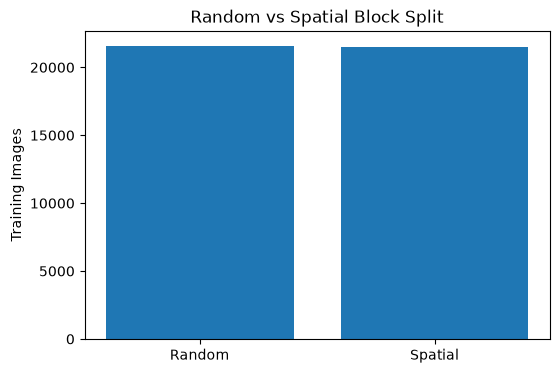

In [10]:
plt.figure(figsize=(6,4))

plt.bar(
    ["Random", "Spatial"],
    [
        len(random_train),
        len(spatial_train)
    ]
)

plt.ylabel("Training Images")

plt.title("Random vs Spatial Block Split")

plt.show()

In [11]:
print("""
Spatial Leakage Explanation
---------------------------

Random Split:
Images are randomly distributed between training and validation.
Neighbouring or visually similar tiles may appear in both sets,
leading to optimistic evaluation.

Spatial Block Split:
Entire blocks are assigned to either training or validation.
This better simulates deployment on unseen geographic regions
and provides a more realistic estimate of model performance.
""")


Spatial Leakage Explanation
---------------------------

Random Split:
Images are randomly distributed between training and validation.
Neighbouring or visually similar tiles may appear in both sets,
leading to optimistic evaluation.

Spatial Block Split:
Entire blocks are assigned to either training or validation.
This better simulates deployment on unseen geographic regions
and provides a more realistic estimate of model performance.

